In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [43]:
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [44]:
X = df

In [45]:
wcss = []

for k in range(1,11):

    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)

    wcss.append(kmeans.inertia_)

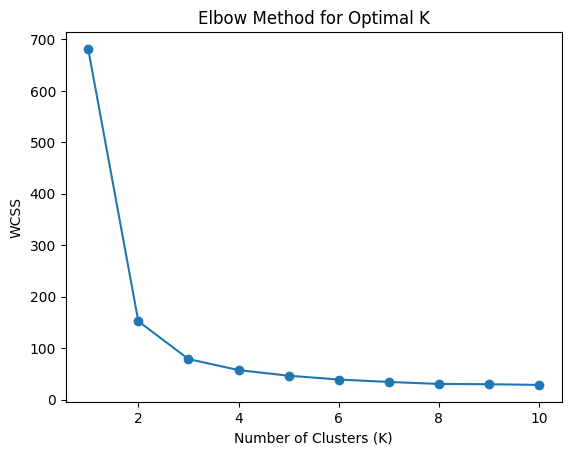

In [46]:
plt.figure()
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal K")
plt.show()

In [47]:
silhouette_scores = []

for k in range(2,11):

    kmeans = KMeans(n_clusters=k, random_state=42)

    labels = kmeans.fit_predict(X)

    score = silhouette_score(X, labels)

    silhouette_scores.append(score)

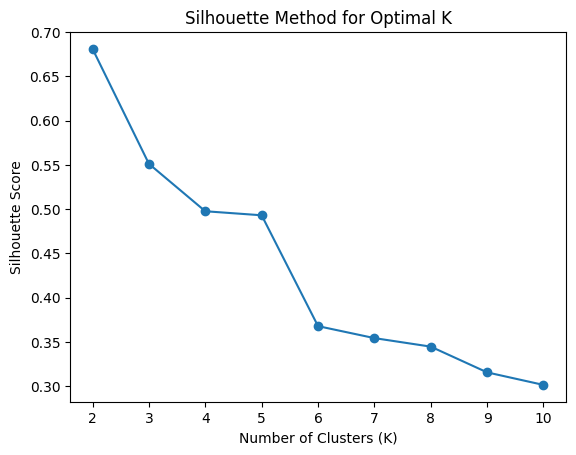

In [48]:
plt.figure()

plt.plot(range(2,11), silhouette_scores, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.title("Silhouette Method for Optimal K")

plt.show()

In [49]:
kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(X)

df['Cluster'] = clusters

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Cluster
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1


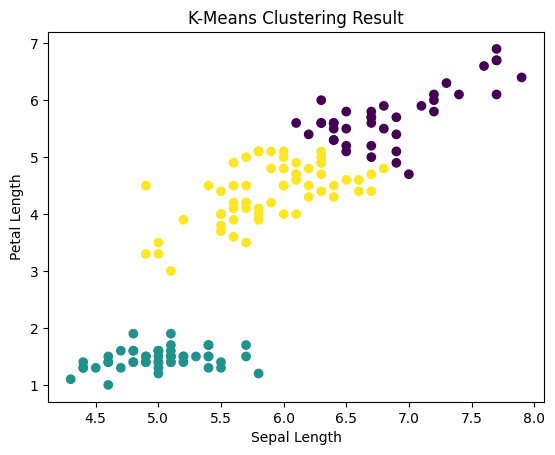

In [50]:
plt.figure()

plt.scatter(df['sepal length (cm)'], df['petal length (cm)'], c=df['Cluster'])

plt.xlabel("Sepal Length")

plt.ylabel("Petal Length")

plt.title("K-Means Clustering Result")

plt.show()

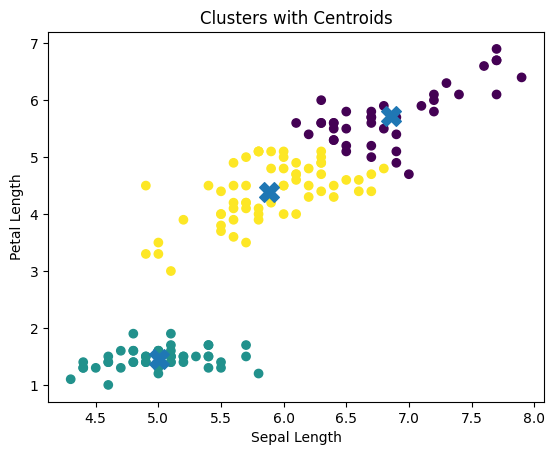

In [51]:
plt.figure()

plt.scatter(df['sepal length (cm)'], df['petal length (cm)'], c=df['Cluster'])

centroids = kmeans.cluster_centers_

plt.scatter(centroids[:,0], centroids[:,2], marker='X', s=200)

plt.xlabel("Sepal Length")

plt.ylabel("Petal Length")

plt.title("Clusters with Centroids")

plt.show()